In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_test = pd.read_csv(
    "../data/processed/online_retail_clean.csv",
    nrows=10
)

df_test

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,YearMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850,United Kingdom,15.30,2010-12
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850,United Kingdom,25.50,2010-12
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850,United Kingdom,11.10,2010-12
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850,United Kingdom,11.10,2010-12
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047,United Kingdom,54.08,2010-12


Load only the columns we need

In [3]:
df_clean = pd.read_csv(
    "../data/processed/online_retail_clean.csv",
    usecols=[
        "InvoiceNo",
        "StockCode",
        "InvoiceDate",
        "Quantity",
        "UnitPrice",
        "CustomerID"
    ],
    parse_dates=["InvoiceDate"]
)

print(f"Dataset shape: {df_clean.shape}")
print(df_clean.memory_usage(deep=True).sum() / 1024**2, "MB")

Dataset shape: (392692, 6)
35.232333183288574 MB


Re-create Revenue

In [4]:
df_clean["Revenue"] = (
    df_clean["Quantity"] * df_clean["UnitPrice"]
)

In [5]:
df_clean.head()

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Revenue
0,536365,85123A,6,2010-12-01 08:26:00,2.55,17850,15.30
1,536365,71053,6,2010-12-01 08:26:00,3.39,17850,20.34
2,536365,84406B,8,2010-12-01 08:26:00,2.75,17850,22.00
3,536365,84029G,6,2010-12-01 08:26:00,3.39,17850,20.34
4,536365,84029E,6,2010-12-01 08:26:00,3.39,17850,20.34


In [6]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  int64         
 1   StockCode    392692 non-null  str           
 2   Quantity     392692 non-null  int64         
 3   InvoiceDate  392692 non-null  datetime64[us]
 4   UnitPrice    392692 non-null  float64       
 5   CustomerID   392692 non-null  int64         
 6   Revenue      392692 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(3), str(1)
memory usage: 21.0 MB


Step 20 — Add ActiveMonths

In [8]:
analysis_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Analysis date:", analysis_date)

Analysis date: 2011-12-10 12:50:00


In [9]:
rfm = (
    df_clean
    .groupby("CustomerID")
    .agg(
        Recency=(
            "InvoiceDate",
            lambda x: (analysis_date - x.max()).days
        ),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("Revenue", "sum")
    )
    .reset_index()
)

print(f"Number of customers: {len(rfm):,}")
rfm.head()

Number of customers: 4,338


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [10]:
quantity_features = (
    df_clean
    .groupby("CustomerID")
    .agg(
        TotalQuantity=("Quantity", "sum"),
        UniqueProducts=("StockCode", "nunique")
    )
    .reset_index()
)

rfm = rfm.merge(
    quantity_features,
    on="CustomerID",
    how="left"
)

rfm["AverageOrderValue"] = (
    rfm["Monetary"] / rfm["Frequency"]
)

In [11]:
lifespan = (
    df_clean
    .groupby("CustomerID")["InvoiceDate"]
    .agg(
        FirstPurchase="min",
        LastPurchase="max"
    )
    .reset_index()
)

lifespan["CustomerLifespanDays"] = (
    lifespan["LastPurchase"] -
    lifespan["FirstPurchase"]
).dt.days

rfm = rfm.merge(
    lifespan[
        [
            "CustomerID",
            "FirstPurchase",
            "LastPurchase",
            "CustomerLifespanDays"
        ]
    ],
    on="CustomerID",
    how="left"
)

In [12]:
active_months = (
    df_clean
    .assign(
        YearMonth=df_clean["InvoiceDate"].dt.to_period("M")
    )
    .groupby("CustomerID")["YearMonth"]
    .nunique()
    .reset_index(name="ActiveMonths")
)

rfm = rfm.merge(
    active_months,
    on="CustomerID",
    how="left"
)

In [13]:
rfm["OrdersPerActiveMonth"] = (
    rfm["Frequency"] / rfm["ActiveMonths"]
)

In [14]:
rfm[[
    "CustomerID",
    "Recency",
    "Frequency",
    "Monetary",
    "ActiveMonths",
    "OrdersPerActiveMonth",
    "UniqueProducts",
    "AverageOrderValue"
]].head(10)

,CustomerID,Recency,Frequency,Monetary,ActiveMonths,OrdersPerActiveMonth,UniqueProducts,AverageOrderValue
0,12346,326,1,77183.60,1,1.0,1,77183.600000
1,12347,2,7,4310.00,7,1.0,103,615.714286
2,12348,75,4,1797.24,4,1.0,22,449.310000
3,12349,19,1,1757.55,1,1.0,73,1757.550000
4,12350,310,1,334.40,1,1.0,17,334.400000
5,12352,36,8,2506.04,4,2.0,59,313.255000
6,12353,204,1,89.00,1,1.0,4,89.000000
7,12354,232,1,1079.40,1,1.0,58,1079.400000
8,12355,214,1,459.40,1,1.0,13,459.400000
9,12356,23,3,2811.43,3,1.0,53,937.143333


Step 21 — Create RFM scores

In [15]:
rfm["RecencyScore"] = pd.qcut(
    rfm["Recency"],
    q=5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

Frequency score

In [16]:
rfm["FrequencyScore"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

Monetary score

In [17]:
rfm["MonetaryScore"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

combined RFM score

In [18]:
rfm["RFM_Score"] = (
    rfm["RecencyScore"] +
    rfm["FrequencyScore"] +
    rfm["MonetaryScore"]
)

In [19]:
rfm[[
    "CustomerID",
    "Recency",
    "Frequency",
    "Monetary",
    "RecencyScore",
    "FrequencyScore",
    "MonetaryScore",
    "RFM_Score"
]].head(20)

,CustomerID,Recency,Frequency,Monetary,RecencyScore,FrequencyScore,MonetaryScore,RFM_Score
0,12346,326,1,77183.60,1,1,5,7
1,12347,2,7,4310.00,5,5,5,15
2,12348,75,4,1797.24,2,4,4,10
3,12349,19,1,1757.55,4,1,4,9
4,12350,310,1,334.40,1,1,2,4
5,12352,36,8,2506.04,3,5,5,13
6,12353,204,1,89.00,1,1,1,3
7,12354,232,1,1079.40,1,1,4,6
8,12355,214,1,459.40,1,1,2,4
9,12356,23,3,2811.43,4,3,5,12


In [20]:
print("Recency scores:")
print(rfm["RecencyScore"].value_counts().sort_index())

print("\nFrequency scores:")
print(rfm["FrequencyScore"].value_counts().sort_index())

print("\nMonetary scores:")
print(rfm["MonetaryScore"].value_counts().sort_index())

print("\nRFM score distribution:")
print(rfm["RFM_Score"].value_counts().sort_index())

Recency scores:
RecencyScore
1    865
2    843
3    858
4    904
5    868
Name: count, dtype: int64

Frequency scores:
FrequencyScore
1    868
2    867
3    868
4    867
5    868
Name: count, dtype: int64

Monetary scores:
MonetaryScore
1    868
2    867
3    868
4    867
5    868
Name: count, dtype: int64

RFM score distribution:
RFM_Score
3     183
4     361
5     337
6     426
7     377
8     375
9     336
10    342
11    347
12    321
13    286
14    300
15    347
Name: count, dtype: int64


Step 22 — Create RFM customer segments

In [21]:
def assign_rfm_segment(row):
    r = row["RecencyScore"]
    f = row["FrequencyScore"]
    m = row["MonetaryScore"]

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"

    elif f >= 4 and m >= 4 and r >= 3:
        return "Loyal Customers"

    elif r >= 4 and f >= 3:
        return "Potential Loyalists"

    elif r >= 4 and f <= 2 and m <= 3:
        return "New Customers"

    elif r >= 3 and f >= 2 and m >= 2:
        return "Promising Customers"

    elif r <= 2 and f >= 4 and m >= 4:
        return "Can't Lose Them"

    elif r <= 2 and f >= 3:
        return "At Risk"

    elif r <= 2 and f <= 2 and m >= 3:
        return "Hibernating"

    else:
        return "Lost Customers"

In [22]:
rfm["Segment"] = rfm.apply(
    assign_rfm_segment,
    axis=1
)

In [23]:
segment_counts = (
    rfm["Segment"]
    .value_counts()
    .rename_axis("Segment")
    .reset_index(name="Customers")
)

segment_counts["Percentage"] = (
    segment_counts["Customers"] /
    len(rfm) * 100
)

segment_counts

,Segment,Customers,Percentage
0,Lost Customers,1080,24.896266
1,Champions,957,22.060858
2,Potential Loyalists,496,11.433840
3,At Risk,475,10.949746
4,Promising Customers,395,9.105579
5,New Customers,288,6.639004
6,Hibernating,244,5.624712
7,Loyal Customers,235,5.417243
8,Can't Lose Them,168,3.872752


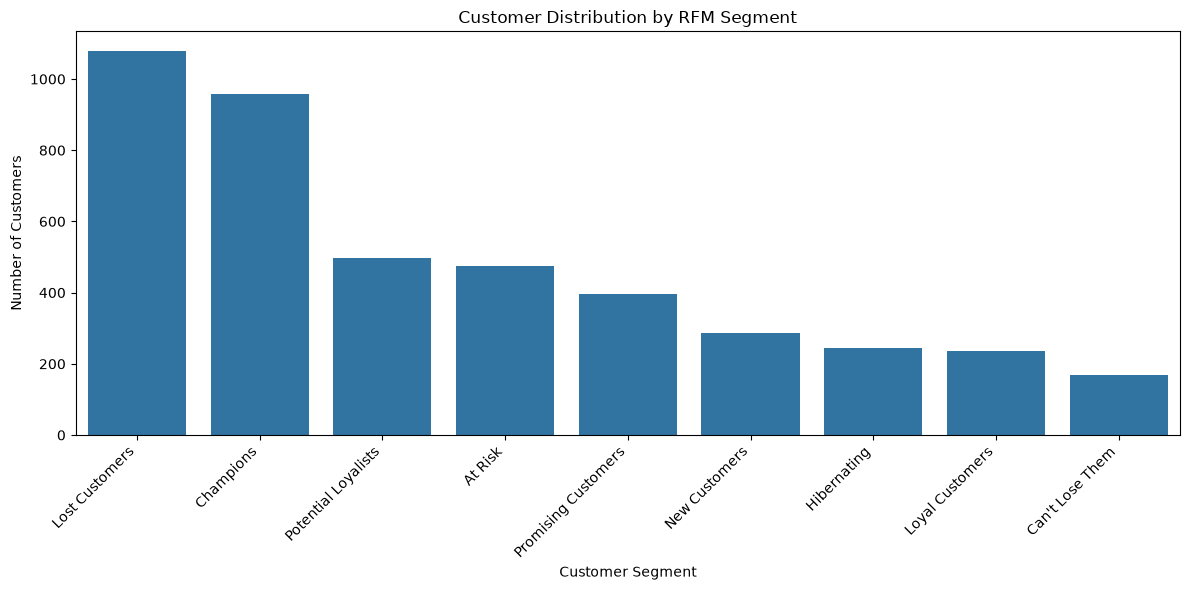

In [28]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=segment_counts,
    x="Segment",
    y="Customers"
)

plt.title("Customer Distribution by RFM Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [29]:
segment_profile = (
    rfm
    .groupby("Segment")
    .agg(
        Customers=("CustomerID", "count"),
        AvgRecency=("Recency", "mean"),
        AvgFrequency=("Frequency", "mean"),
        AvgMonetary=("Monetary", "mean"),
        AvgActiveMonths=("ActiveMonths", "mean"),
        AvgOrdersPerActiveMonth=("OrdersPerActiveMonth", "mean"),
        AvgUniqueProducts=("UniqueProducts", "mean"),
        AvgOrderValue=("AverageOrderValue", "mean")
    )
    .sort_values("AvgMonetary", ascending=False)
)

segment_profile

,Customers,AvgRecency,AvgFrequency,AvgMonetary,AvgActiveMonths,AvgOrdersPerActiveMonth,AvgUniqueProducts,AvgOrderValue
Segment,,,,,,,,
Champions,957,12.824451,11.123302,6051.871202,6.518286,1.554102,136.562173,467.162319
Loyal Customers,235,50.434043,6.378723,3061.340894,4.834043,1.337655,98.587234,463.681921
Can't Lose Them,168,125.559524,5.529762,2205.350298,4.047619,1.532396,74.666667,422.360228
Hibernating,244,183.495902,1.299180,1355.297791,1.250000,1.049180,37.372951,1169.396703
Potential Loyalists,496,16.161290,2.951613,1077.675143,2.556452,1.210033,54.570565,437.454414
At Risk,475,162.494737,2.652632,900.112971,2.292632,1.226789,37.901053,347.232382
Promising Customers,395,50.286076,2.326582,857.636557,2.174684,1.096184,48.951899,418.761336
New Customers,288,18.670139,1.190972,315.657535,1.163194,1.027778,26.895833,268.349358
Lost Customers,1080,186.101852,1.070370,262.227029,1.059259,1.008951,17.702778,254.453871


In [30]:
segment_median_profile = (
    rfm
    .groupby("Segment")
    .agg(
        Customers=("CustomerID", "count"),
        MedianRecency=("Recency", "median"),
        MedianFrequency=("Frequency", "median"),
        MedianMonetary=("Monetary", "median"),
        MedianActiveMonths=("ActiveMonths", "median"),
        MedianOrdersPerActiveMonth=("OrdersPerActiveMonth", "median"),
        MedianUniqueProducts=("UniqueProducts", "median"),
        MedianOrderValue=("AverageOrderValue", "median")
    )
)

segment_median_profile

,Customers,MedianRecency,MedianFrequency,MedianMonetary,MedianActiveMonths,MedianOrdersPerActiveMonth,MedianUniqueProducts,MedianOrderValue
Segment,,,,,,,,
At Risk,475,154.0,2.0,591.550,2.0,1.000000,29.0,211.300000
Can't Lose Them,168,107.0,5.0,1713.600,4.0,1.250000,66.0,383.307500
Champions,957,10.0,7.0,2633.850,6.0,1.333333,100.0,352.214167
Hibernating,244,166.0,1.0,760.095,1.0,1.000000,32.0,619.817500
Lost Customers,1080,185.0,1.0,214.290,1.0,1.000000,13.0,204.800000
Loyal Customers,235,50.0,5.0,2062.700,5.0,1.200000,84.0,375.025000
New Customers,288,19.0,1.0,277.805,1.0,1.000000,20.0,228.070000
Potential Loyalists,496,16.0,3.0,654.900,2.0,1.000000,41.0,207.297500
Promising Customers,395,51.0,2.0,661.520,2.0,1.000000,36.0,321.385000


Step 23 — Save the RFM dataset

In [32]:
rfm.to_csv(
    "../data/processed/customer_rfm_features.csv",
    index=False
)

print("RFM dataset saved successfully.")
print("Shape:", rfm.shape)

RFM dataset saved successfully.
Shape: (4338, 17)


Step 24 — Prepare features for K-Means

In [34]:
import numpy as np
from sklearn.preprocessing import StandardScaler

cluster_features = [
    "Recency",
    "Frequency",
    "Monetary",
    "ActiveMonths",
    "OrdersPerActiveMonth",
    "UniqueProducts",
    "AverageOrderValue"
]

X_cluster = rfm[cluster_features].copy()

# Log-transform skewed features
for col in cluster_features:
    X_cluster[col] = np.log1p(X_cluster[col])

# Standardize features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=cluster_features,
    index=rfm.index
)

print("Clustering features shape:", X_scaled.shape)

print("\nScaled feature summary:")
display(X_scaled.describe().round(2))

Clustering features shape: (4338, 7)

Scaled feature summary:


,Recency,Frequency,Monetary,ActiveMonths,OrdersPerActiveMonth,UniqueProducts,AverageOrderValue
count,4338.00,4338.00,4338.00,4338.00,4338.00,4338.00,4338.00
mean,-0.00,-0.00,-0.00,0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.34,-0.96,-4.00,-0.99,-0.49,-2.53,-5.57
25%,-0.66,-0.96,-0.68,-0.99,-0.49,-0.63,-0.62
50%,0.09,-0.36,-0.07,-0.24,-0.49,0.03,0.05
75%,0.84,0.65,0.66,0.71,0.18,0.71,0.56
max,1.56,5.86,4.73,2.62,15.89,3.48,7.64


Step 25 — Evaluate candidate K values

In [35]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouette_scores = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(X_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(X_scaled, cluster_labels)
    )

results = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertias,
    "SilhouetteScore": silhouette_scores
})

results

,K,Inertia,SilhouetteScore
0,2,18502.430693,0.357967
1,3,15330.421380,0.259515
2,4,13409.580813,0.222272
3,5,12190.662745,0.213349
4,6,11275.436221,0.212073
5,7,10396.785299,0.223578
6,8,9722.204108,0.207450
7,9,9156.997959,0.200794
8,10,8690.853706,0.200288


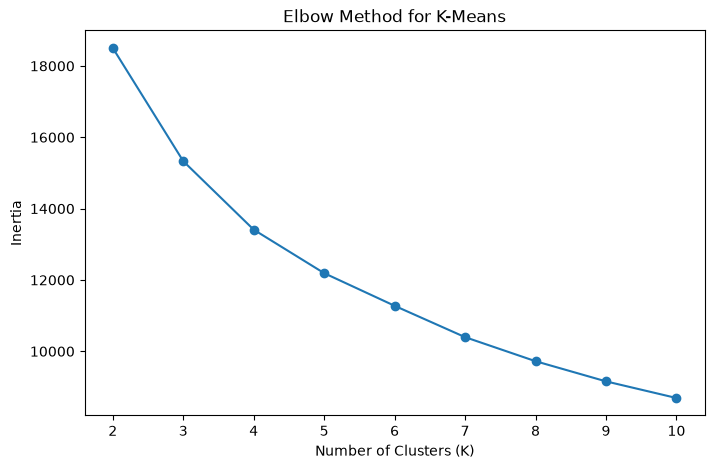

In [36]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    results["K"],
    results["Inertia"],
    marker="o"
)

ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Inertia")
ax.set_title("Elbow Method for K-Means")
ax.set_xticks(results["K"])

plt.show()

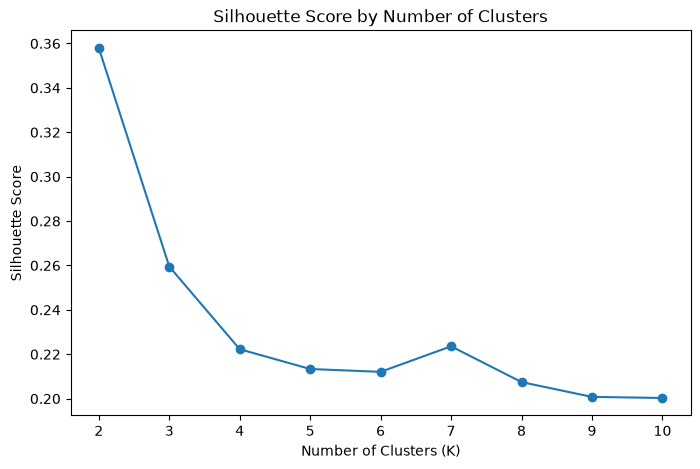

In [37]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    results["K"],
    results["SilhouetteScore"],
    marker="o"
)

ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Silhouette Score")
ax.set_title("Silhouette Score by Number of Clusters")
ax.set_xticks(results["K"])

plt.show()

Step 26 — Compare candidate cluster profiles

In [38]:
candidate_profiles = {}

for k in [2, 3, 4, 5]:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    temp = rfm[cluster_features].copy()
    temp["Cluster"] = labels

    profile = (
        temp
        .groupby("Cluster")
        .agg(
            Customers=("Recency", "count"),
            AvgRecency=("Recency", "mean"),
            AvgFrequency=("Frequency", "mean"),
            AvgMonetary=("Monetary", "mean"),
            AvgActiveMonths=("ActiveMonths", "mean"),
            AvgOrdersPerActiveMonth=("OrdersPerActiveMonth", "mean"),
            AvgUniqueProducts=("UniqueProducts", "mean"),
            AvgOrderValue=("AverageOrderValue", "mean")
        )
        .sort_values("AvgMonetary", ascending=False)
    )

    candidate_profiles[k] = profile

    print(f"\n{'=' * 70}")
    print(f"K = {k}")
    print(f"{'=' * 70}")
    display(profile.round(2))


K = 2


,Customers,AvgRecency,AvgFrequency,AvgMonetary,AvgActiveMonths,AvgOrdersPerActiveMonth,AvgUniqueProducts,AvgOrderValue
Cluster,,,,,,,,
0,1655,32.19,8.52,4605.54,5.39,1.47,117.21,587.24
1,2683,129.76,1.65,471.50,1.54,1.07,27.14,313.03



K = 3


,Customers,AvgRecency,AvgFrequency,AvgMonetary,AvgActiveMonths,AvgOrdersPerActiveMonth,AvgUniqueProducts,AvgOrderValue
Cluster,,,,,,,,
1,725,18.78,13.93,7825.20,7.53,1.81,160.29,495.96
2,1780,59.63,3.33,1501.58,2.95,1.16,65.76,569.04
0,1833,153.66,1.37,295.22,1.28,1.06,18.29,239.65



K = 4


,Customers,AvgRecency,AvgFrequency,AvgMonetary,AvgActiveMonths,AvgOrdersPerActiveMonth,AvgUniqueProducts,AvgOrderValue
Cluster,,,,,,,,
1,465,17.09,17.49,10735.45,8.41,2.08,185.86,567.98
3,1418,37.20,4.73,1796.16,4.02,1.20,82.16,431.29
0,1340,130.95,1.54,837.64,1.45,1.07,36.35,576.57
2,1115,148.21,1.47,202.54,1.35,1.08,13.58,146.61



K = 5


,Customers,AvgRecency,AvgFrequency,AvgMonetary,AvgActiveMonths,AvgOrdersPerActiveMonth,AvgUniqueProducts,AvgOrderValue
Cluster,,,,,,,,
1,229,13.63,24.83,16965.90,9.56,2.68,212.97,650.77
2,942,30.30,6.94,3174.38,5.48,1.27,120.43,565.25
0,1074,147.32,1.36,906.00,1.31,1.04,33.47,656.98
4,1122,50.43,3.19,771.86,2.75,1.21,50.52,254.05
3,971,159.58,1.31,177.84,1.24,1.06,12.30,143.79


Step 27 — Let's inspect K=4 more carefully

In [39]:
k = 4

kmeans_final = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

rfm["KMeansCluster"] = kmeans_final.fit_predict(X_scaled)

cluster_segment_crosstab = pd.crosstab(
    rfm["KMeansCluster"],
    rfm["Segment"],
    normalize="index"
) * 100

cluster_segment_crosstab.round(1)

Segment,At Risk,Can't Lose Them,Champions,Hibernating,Lost Customers,Loyal Customers,New Customers,Potential Loyalists,Promising Customers
KMeansCluster,,,,,,,,,
0,17.6,1.5,0.3,18.1,30.6,0.3,9.5,5.4,16.7
1,0.0,3.7,89.9,0.0,0.0,5.8,0.0,0.4,0.2
2,15.2,0.0,0.0,0.2,60.1,0.0,13.2,8.0,3.4
3,4.9,9.2,37.7,0.0,0.0,14.4,1.0,23.4,9.3


Step 28 — Assign business names to the K=4 clusters

| Cluster | Profile                                                            | Proposed analytical name         |
| ------: | ------------------------------------------------------------------ | -------------------------------- |
|   **1** | Very recent, extremely frequent, highest monetary value            | **High-Value Champions**         |
|   **3** | Active/recent, moderate-to-high frequency and value                | **Engaged Loyal Customers**      |
|   **0** | Relatively inactive, but considerably more valuable than Cluster 2 | **At-Risk Valuable Customers**   |
|   **2** | Most inactive, lowest frequency and monetary value                 | **Low-Value Inactive Customers** |


In [40]:
cluster_names = {
    0: "At-Risk Valuable Customers",
    1: "High-Value Champions",
    2: "Low-Value Inactive Customers",
    3: "Engaged Loyal Customers"
}

rfm["BehavioralSegment"] = rfm["KMeansCluster"].map(
    cluster_names
)

rfm["BehavioralSegment"].value_counts()

BehavioralSegment
Engaged Loyal Customers         1418
At-Risk Valuable Customers      1340
Low-Value Inactive Customers    1115
High-Value Champions             465
Name: count, dtype: int64

In [41]:
behavioral_profile = (
    rfm
    .groupby("BehavioralSegment")
    .agg(
        Customers=("CustomerID", "count"),
        AvgRecency=("Recency", "mean"),
        AvgFrequency=("Frequency", "mean"),
        AvgMonetary=("Monetary", "mean"),
        AvgActiveMonths=("ActiveMonths", "mean"),
        AvgOrdersPerActiveMonth=("OrdersPerActiveMonth", "mean"),
        AvgUniqueProducts=("UniqueProducts", "mean"),
        AvgOrderValue=("AverageOrderValue", "mean")
    )
    .sort_values("AvgMonetary", ascending=False)
)

behavioral_profile.round(2)

,Customers,AvgRecency,AvgFrequency,AvgMonetary,AvgActiveMonths,AvgOrdersPerActiveMonth,AvgUniqueProducts,AvgOrderValue
BehavioralSegment,,,,,,,,
High-Value Champions,465,17.09,17.49,10735.45,8.41,2.08,185.86,567.98
Engaged Loyal Customers,1418,37.20,4.73,1796.16,4.02,1.20,82.16,431.29
At-Risk Valuable Customers,1340,130.95,1.54,837.64,1.45,1.07,36.35,576.57
Low-Value Inactive Customers,1115,148.21,1.47,202.54,1.35,1.08,13.58,146.61


Step 29 — Visualize the behavioral segments

In [42]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=rfm.index
)

pca_df["BehavioralSegment"] = rfm["BehavioralSegment"]

print(
    "Explained variance:",
    pca.explained_variance_ratio_.round(3)
)

print(
    "Total explained variance:",
    round(pca.explained_variance_ratio_.sum(), 3)
)

Explained variance: [0.59  0.169]
Total explained variance: 0.759


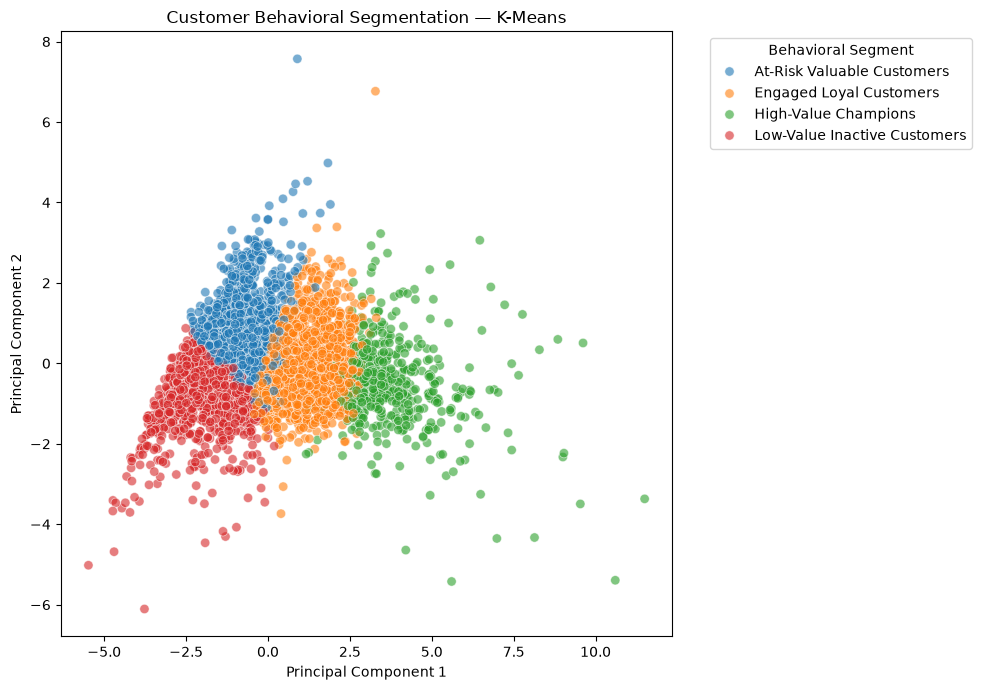

In [43]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="BehavioralSegment",
    alpha=0.6,
    s=45
)

plt.title("Customer Behavioral Segmentation — K-Means")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(
    title="Behavioral Segment",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [45]:
rfm.to_csv(
    "../data/processed/customer_segmentation.csv",
    index=False
)

print("Customer segmentation dataset saved successfully.")
print("Shape:", rfm.shape)

Customer segmentation dataset saved successfully.
Shape: (4338, 19)
